### This notebook was used to run the DB-DOI training for Fig 4 which takes about 30 mins


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from copy import deepcopy

from qibo.backends import construct_backend
from qibo import hamiltonians, Circuit, gates, set_backend
from qibo import gates, symbols
from qibo.gates import Unitary, CNOT, CZ
from qibo.symbols import X, Y, Z
from qibo import hamiltonians
from qibo.hamiltonians import Hamiltonian, SymbolicHamiltonian

from db_doi.group_commutator_iteration import GroupCommutatorIteration, DoubleBracketRotationApproximationType
from db_doi.utils_XXZ_compilation import *

/home/marek/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
from db_doi.utils_reporting import load_data, fidelity_witness, save_data,two_qubit_counter

HVA_results = {}
HVA_energies = load_data("simulation_results/Qibo_HVA/training_run_1.0/" + f"energies")
for L in HVA_energies['Ls']:
    HVA_results[L] = load_data("simulation_results/Qibo_HVA/training_run_1.0/" + f"XXZ_HVA_data_L{L}")
selected_circuits = load_data("simulation_results/Qibo_HVA/training_run_1.0/" + f"selected_HVA_circuits")

Set the following variable to True to execute the training, otherwise the code assumes the pickled data is present. $p=1$ takes less than 4 mins but altogether the DB-DOI training will need about 1h.

In [3]:
please_run_training = True

[Qibo 0.2.21|INFO|2025-08-19 20:29:40]: Using qibojit (numba) backend on /CPU:0


-33.81873621456868 -33.81873621456868 -34.72989333759567
DoubleBracketRotationApproximationType.group_commutator_reduced
--------------------------
Step 1
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-33.844004437294544), np.float64(-34.03830684772874), np.float64(-34.15428205033836), np.float64(-34.20621746256167), np.float64(-34.20315533004707), np.float64(-34.15164891785295), np.float64(-34.05672663545202)]
Optimal step: 0.01525
Minimum loss: -34.20621746256167


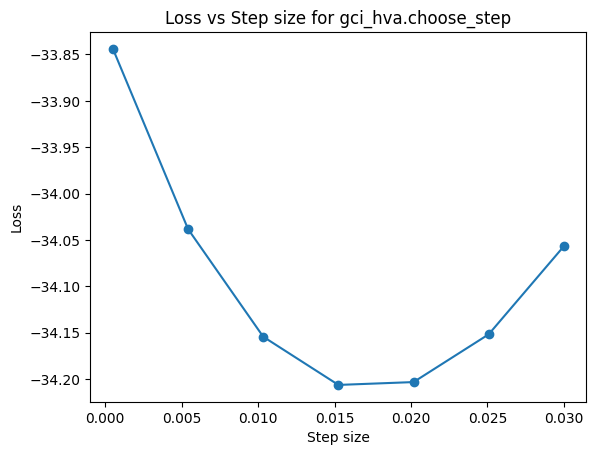

--------------------------
Step 2
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.217859303432455), np.float64(-34.31053429100802), np.float64(-34.37050311183458), np.float64(-34.40479692783261), np.float64(-34.41853718504482), np.float64(-34.41543013192387), np.float64(-34.39806063327785)]
Optimal step: 0.020166666666666666
Minimum loss: -34.41853718504482


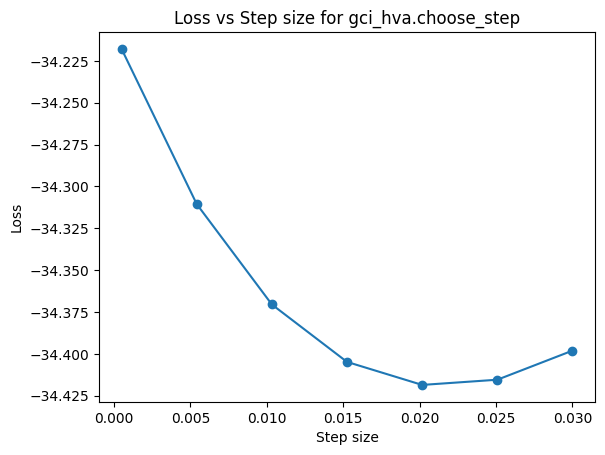

--------------------------
Step 3
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.42707414809538), np.float64(-34.48990118200417), np.float64(-34.52100834128959), np.float64(-34.52937908725799), np.float64(-34.521023451536436), np.float64(-34.499533648746095), np.float64(-34.46675813262394)]
Optimal step: 0.01525
Minimum loss: -34.52937908725799


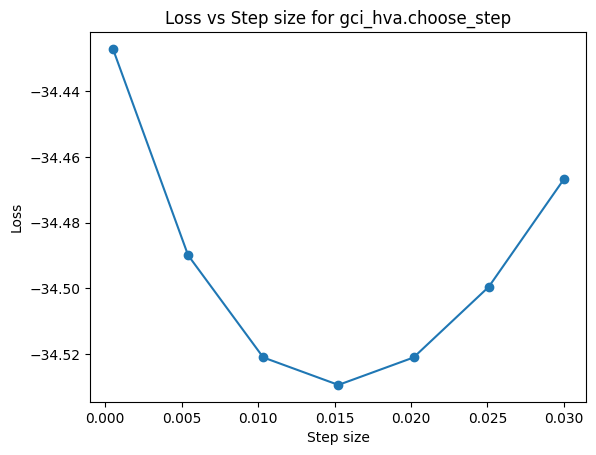

The function took 146.8318 seconds to execute.
-34.07624263435968 -34.07624263435968 -34.72989333759567
DoubleBracketRotationApproximationType.group_commutator_reduced
--------------------------
Step 1
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.099548438112166), np.float64(-34.26284223748213), np.float64(-34.334991931222596), np.float64(-34.3389708257668), np.float64(-34.29017652856227), np.float64(-34.19957531812005), np.float64(-34.07498847160852)]
Optimal step: 0.01525
Minimum loss: -34.3389708257668


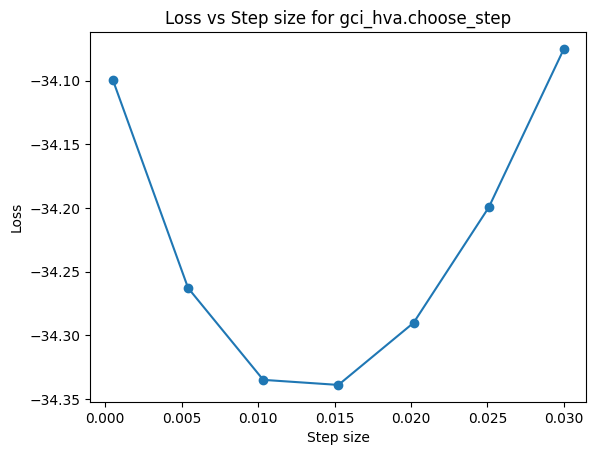

--------------------------
Step 2
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.349617946398695), np.float64(-34.428237259081406), np.float64(-34.47061364401053), np.float64(-34.48703282250586), np.float64(-34.48413417873369), np.float64(-34.46618677558007), np.float64(-34.43581143992259)]
Optimal step: 0.01525
Minimum loss: -34.48703282250586


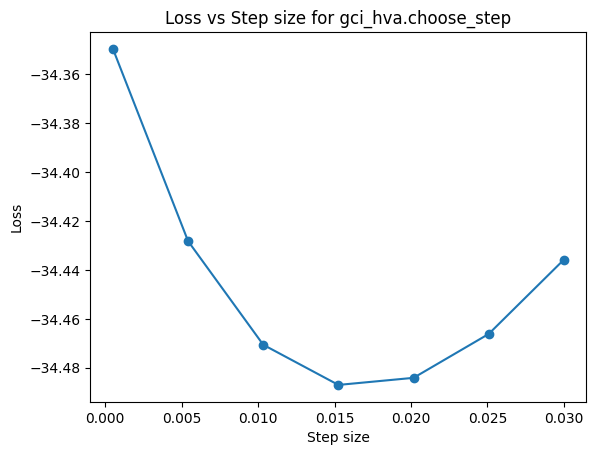

--------------------------
Step 3
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.49535823294014), np.float64(-34.5432184536681), np.float64(-34.54976715976792), np.float64(-34.53527378687957), np.float64(-34.51022794370909), np.float64(-34.47904143203587), np.float64(-34.44260220976885)]
Optimal step: 0.010333333333333333
Minimum loss: -34.54976715976792


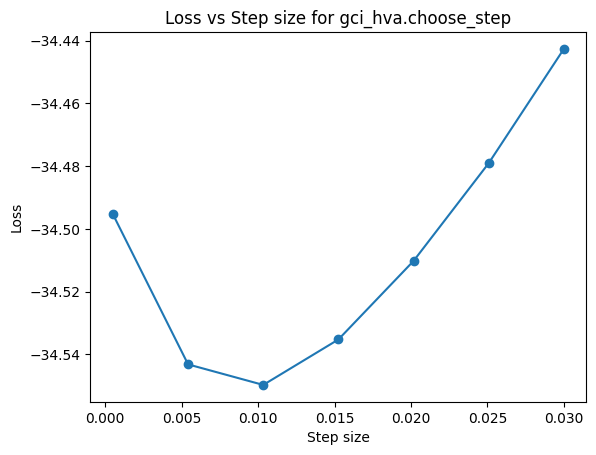

The function took 200.1984 seconds to execute.
-34.13462170936076 -34.13462170936076 -34.72989333759567
DoubleBracketRotationApproximationType.group_commutator_reduced
--------------------------
Step 1
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.15952319960895), np.float64(-34.32442464477961), np.float64(-34.370248344462354), np.float64(-34.33191376290918), np.float64(-34.23531846636078), np.float64(-34.09849083179685), np.float64(-33.93341326914879)]
Optimal step: 0.010333333333333333
Minimum loss: -34.370248344462354


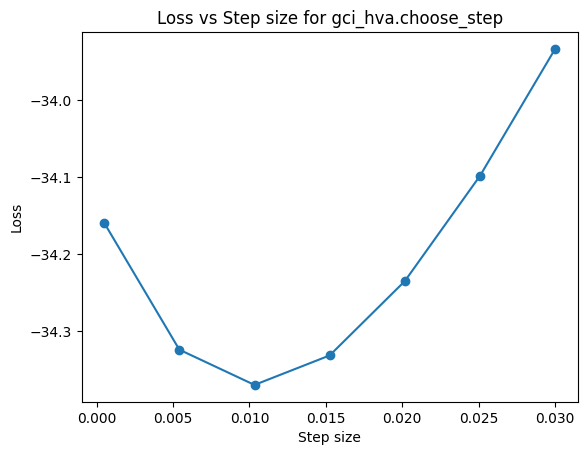

--------------------------
Step 2
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.38139242527596), np.float64(-34.44828198223698), np.float64(-34.462729743701004), np.float64(-34.44690166349096), np.float64(-34.4133650094964), np.float64(-34.368621940344106), np.float64(-34.31527279078149)]
Optimal step: 0.010333333333333333
Minimum loss: -34.462729743701004


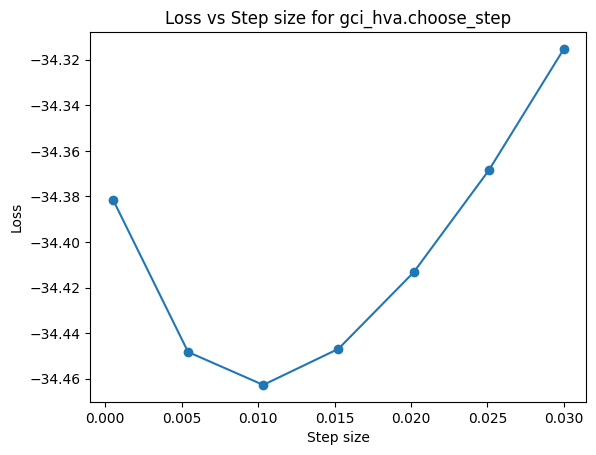

--------------------------
Step 3
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.472042561940874), np.float64(-34.52004892351642), np.float64(-34.51926758019036), np.float64(-34.496708048373215), np.float64(-34.46602116947866), np.float64(-34.432857090120734), np.float64(-34.398256109707404)]
Optimal step: 0.005416666666666667
Minimum loss: -34.52004892351642


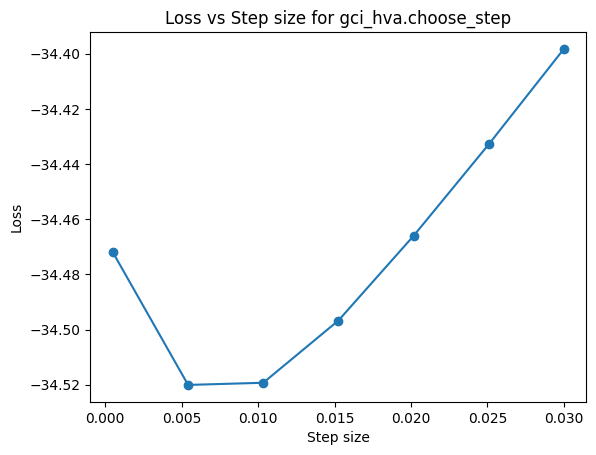

The function took 255.5191 seconds to execute.
-34.050082722212125 -34.050082722212125 -34.72989333759567
DoubleBracketRotationApproximationType.group_commutator_reduced
--------------------------
Step 1
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.080849241453635), np.float64(-34.28169605952664), np.float64(-34.33981714852695), np.float64(-34.29740459674988), np.float64(-34.183508401220664), np.float64(-34.01847239689708), np.float64(-33.81655859109383)]
Optimal step: 0.010333333333333333
Minimum loss: -34.33981714852695


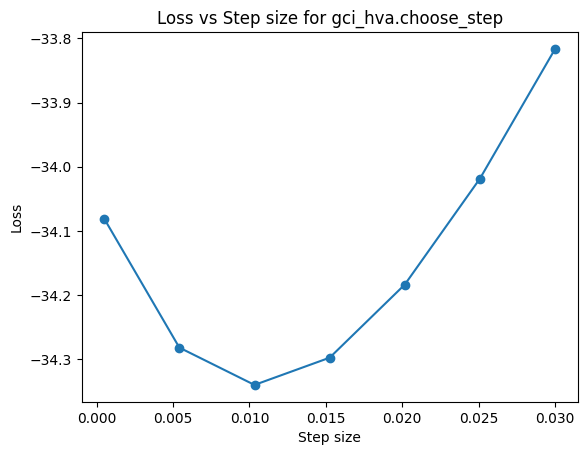

--------------------------
Step 2
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.35497652245597), np.float64(-34.446034615734156), np.float64(-34.46684550193925), np.float64(-34.449002776448374), np.float64(-34.4101876056752), np.float64(-34.35959819592728), np.float64(-34.301203147136185)]
Optimal step: 0.010333333333333333
Minimum loss: -34.46684550193925


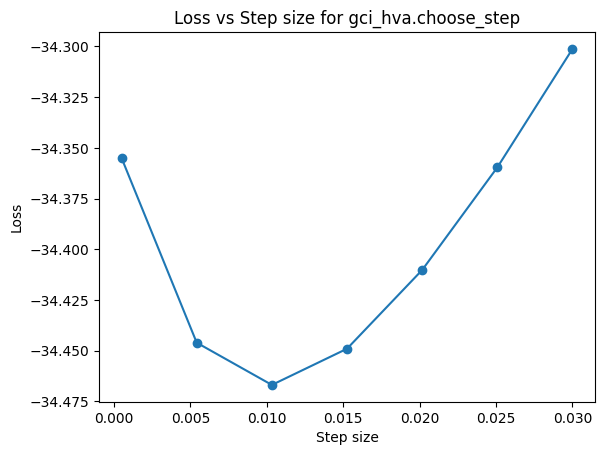

--------------------------
Step 3
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.47890723656719), np.float64(-34.53245777914417), np.float64(-34.51796376164934), np.float64(-34.4789299954177), np.float64(-34.43532172630954), np.float64(-34.39401191485247), np.float64(-34.35500510572624)]
Optimal step: 0.005416666666666667
Minimum loss: -34.53245777914417


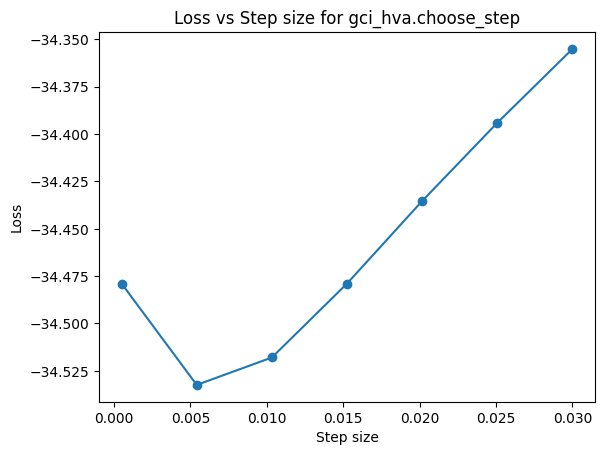

The function took 312.8162 seconds to execute.
-34.46212549222226 -34.46212549222226 -34.72989333759567
DoubleBracketRotationApproximationType.group_commutator_reduced
--------------------------
Step 1
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.468679869547344), np.float64(-34.518545906836906), np.float64(-34.54445288106127), np.float64(-34.547302086335755), np.float64(-34.52729596953808), np.float64(-34.48444866957782), np.float64(-34.418741567916825)]
Optimal step: 0.01525
Minimum loss: -34.547302086335755


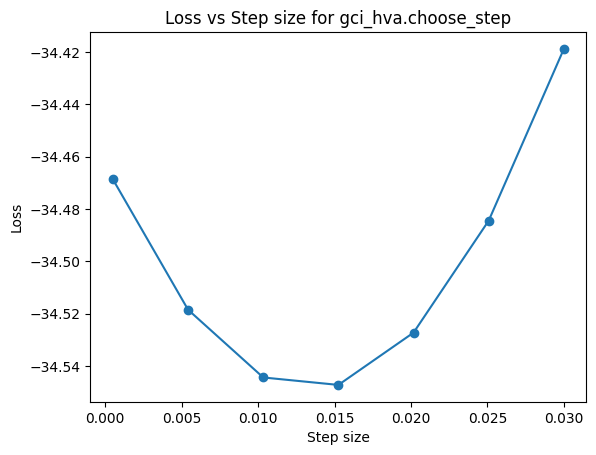

--------------------------
Step 2
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.55141435002011), np.float64(-34.58050122103943), np.float64(-34.594477901315095), np.float64(-34.59725663013302), np.float64(-34.590855217350594), np.float64(-34.576180877807744), np.float64(-34.553398492971844)]
Optimal step: 0.01525
Minimum loss: -34.59725663013302


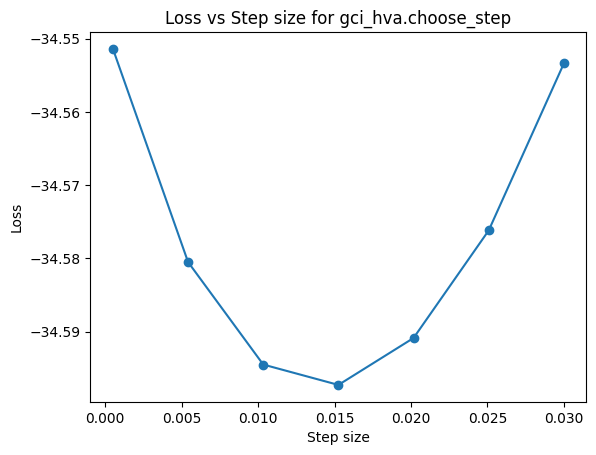

--------------------------
Step 3
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.60050235891504), np.float64(-34.622818529447535), np.float64(-34.63134782401329), np.float64(-34.62958734306993), np.float64(-34.619141930752086), np.float64(-34.600392326421314), np.float64(-34.57296907314862)]
Optimal step: 0.010333333333333333
Minimum loss: -34.63134782401329


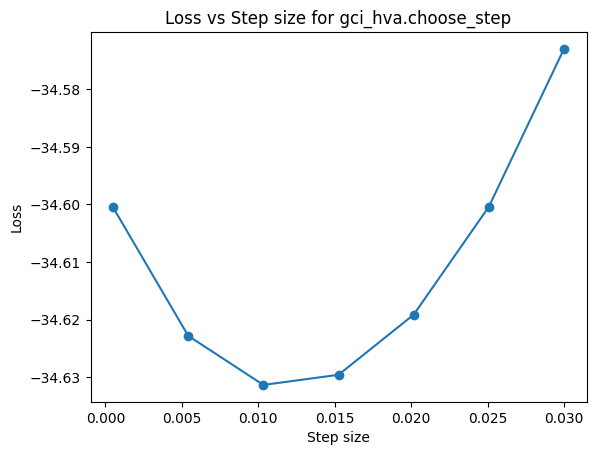

The function took 374.8496 seconds to execute.
-34.541718281441824 -34.541718281441824 -34.72989333759567
DoubleBracketRotationApproximationType.group_commutator_reduced
--------------------------
Step 1
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.54579834427637), np.float64(-34.576020265035865), np.float64(-34.59117147216021), np.float64(-34.59146587387718), np.float64(-34.576128837345045), np.float64(-34.54414283375484), np.float64(-34.49446706880322)]
Optimal step: 0.01525
Minimum loss: -34.59146587387718


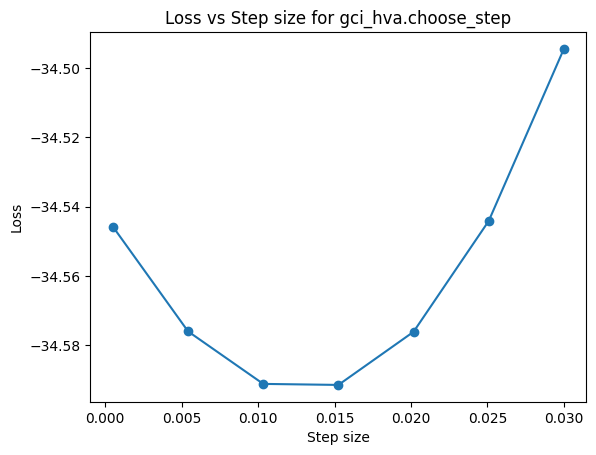

--------------------------
Step 2
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.59448160297207), np.float64(-34.61665367974609), np.float64(-34.62804517408083), np.float64(-34.63042275817025), np.float64(-34.62454272781196), np.float64(-34.6105613809872), np.float64(-34.58822619799502)]
Optimal step: 0.01525
Minimum loss: -34.63042275817025


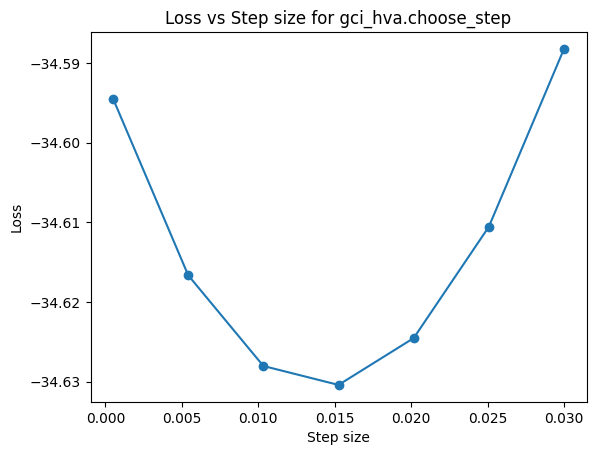

--------------------------
Step 3
Step grid: [0.0005     0.00541667 0.01033333 0.01525    0.02016667 0.02508333
 0.03      ]
Losses: [np.float64(-34.632651476898204), np.float64(-34.64944899976268), np.float64(-34.65757921766743), np.float64(-34.657731999211904), np.float64(-34.64986091719616), np.float64(-34.63342169145465), np.float64(-34.60758708220766)]
Optimal step: 0.01525
Minimum loss: -34.657731999211904


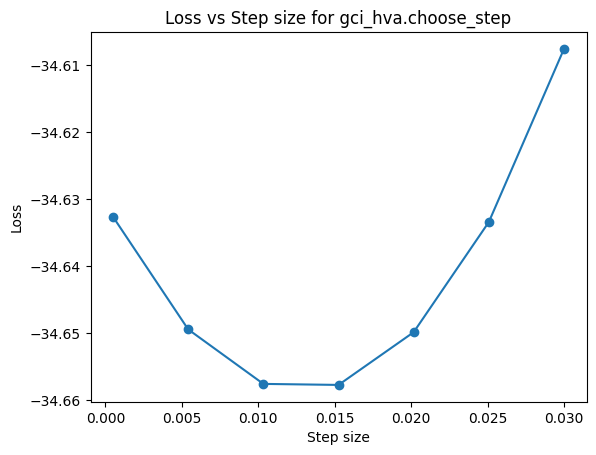

The function took 423.6232 seconds to execute.


In [4]:
L = 20
E0 = HVA_energies['E0_L'][L]
E1 = HVA_energies['E1_L'][L]
import time


if please_run_training: #change this to run the DB-DOI training, otherwise it will be loaded from the github pickle
    db_doi_hva_results = {}
    db_doi_results_steps = {}
    for p in [1,2,3,4,5,6]:
        start_time = time.time()
        db_doi_warmstart_circuit = HVA_results[L][f"HVA_Nlayers_{p}"]['circuit']
        gci = GroupCommutatorIteration(XXZ_compilation_line(L), db_doi_warmstart_circuit, DoubleBracketRotationApproximationType.group_commutator_reduced )
        print(gci.loss(), HVA_results[L][f"HVA_Nlayers_{p}"]['E_HVA'], E0)
        print(gci.double_bracket_rotation_approximation_type)
        from collections import Counter


        doi = hamiltonians.SymbolicHamiltonian( sum([ Z(i) for i in range(L)]))

        
        db_doi_steps = []    
        db_doi_two_qubit_counts = [ two_qubit_counter(db_doi_warmstart_circuit) ]
        db_doi_energies =  [ gci.loss() ]
        db_doi_circuits = [deepcopy(db_doi_warmstart_circuit)]
        db_doi_fidelity_witness = [ fidelity_witness(gci.loss(),E0,E1)]
        for step in range(3):
            print("--------------------------")
            print(f"Step {step+1}")   

            step_grid = np.linspace(0.0005, 0.03, 7)
            s_opt, s_min, losses, _ = gci.choose_step(
                doi, step_grid=step_grid)
            print("Step grid:", step_grid)
            print("Losses:", losses)
            print(f"Optimal step: {s_opt}")
            print(f"Minimum loss: {s_min}")
            db_doi_steps.append(s_opt)
            plt.figure()
            plt.plot(step_grid, losses, marker='o')
            plt.xlabel('Step size')
            plt.ylabel('Loss')
            plt.title('Loss vs Step size for gci_hva.choose_step')
            plt.show()

            gci(s_opt, doi)

            db_doi_two_qubit_counts.append( two_qubit_counter(gci.preparation_circuit))
            db_doi_energies.append(gci.loss())
            db_doi_circuits.append(deepcopy(gci.preparation_circuit))
            db_doi_fidelity_witness.append(fidelity_witness(gci.loss(),E0,E1))
        db_doi_results_steps[p] = {'s_opt': db_doi_steps, 's_min': s_min, 'losses': losses, }
        db_doi_hva_results[p] = {'energies': db_doi_energies, 
                            'cz_counts': db_doi_two_qubit_counts, 
                            'fidelity_witness':db_doi_fidelity_witness,
                            'circuits': db_doi_circuits,
                            's_opt': db_doi_steps}
        end_time = time.time()

        # Calculate the duration
        duration = end_time - start_time

        print(f"The function took {duration:.4f} seconds to execute.")
    save_data(db_doi_hva_results, "simulation_results/Qibo_HVA/reruning_DB_DOI_with_known_s/"+f"XXZ_DB_DOI_HVA_data_L_{L}")
    save_data(db_doi_results_steps, "simulation_results/Qibo_HVA/reruning_DB_DOI_with_known_s/"+f"XXZ_DB_DOI_steps_HVA_data_L_{L}")
    


In [5]:
from db_doi.utils_reporting import *
db_doi_hva_results = load_data( "simulation_results/Qibo_HVA/reruning_DB_DOI_with_known_s/"+f"XXZ_DB_DOI_HVA_data_L_{L}")
db_doi_results_steps = load_data("simulation_results/Qibo_HVA/reruning_DB_DOI_with_known_s/"+f"XXZ_DB_DOI_steps_HVA_data_L_{L}")
    

In [6]:
db_doi_hva_results.keys()

dict_keys([1, 2, 3, 4, 5, 6])

<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_96294/2877322582.py:29: SyntaxWarning: invalid escape sequence '\h'
  ax.set_title("DB-DOI for $L={20}$ qubit $\hat H_{\mathrm{XXX}}$ with HVA warm-start")


[np.float64(-33.811057507777605), np.float64(-34.34553897583189), np.float64(-34.52482487656907), np.float64(-34.59773436094439), np.float64(-34.63561951085654), np.float64(-34.65949516474965)]


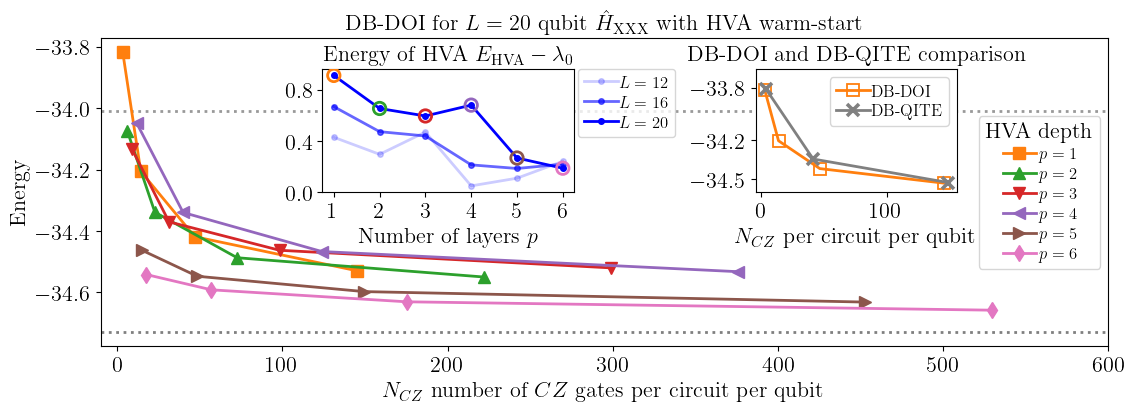

In [8]:
run_param_rc(16)

hva_two_qubit_counts = []
for p in range(1,7):
    hva_two_qubit_counts.append( two_qubit_counter(HVA_results[L][f"HVA_Nlayers_{p}"]['circuit']))

fig, ((ax)) = plt.subplots(1, 1, figsize=(13, 4), 
                                     gridspec_kw={"width_ratios": [1], "height_ratios": [1]})
markers = ['o', 's', '^', 'v', '<', '>', 'd']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

steps = [1,2,3,4,5,6]
#ax0.plot(steps, E_HVA_L[L]-E0_L[L], color=colors[i], marker=markers[i], linestyle='solid', label = rf"$L={L}$")

i=0


#ax.plot(hva_two_qubit_counts, HVA_energies['E_HVA_L'][L], color=colors[i], marker=markers[i], linestyle='solid', label = rf"HVA $L={L}$")
ax.axhline(y=E0, color="black", linestyle=':', alpha=0.5)
ax.axhline(y=E1, color="black", linestyle=':', alpha=0.4)
ax.set_xlabel(r" $N_{CZ}$ number of $CZ$ gates per circuit per qubit")
#ax.grid()
ax.set_ylabel(r"Energy")

for p in [1,2,3,4,5,6]:
    db_doi_energies = db_doi_hva_results[p]['energies']
    db_doi_two_qubit_counts = [ c/ L for c in db_doi_hva_results[p]['cz_counts']]
    ax.plot(db_doi_two_qubit_counts, db_doi_energies, color=colors[p], marker=markers[p], linestyle='solid', label = rf"$p={p}$")
ax.set_title("DB-DOI for $L={20}$ qubit $\hat H_{\mathrm{XXX}}$ with HVA warm-start")



ax.legend(title="HVA depth")#bbox_to_anchor=(1.05, 1), loc='upper left')

ax0 = ax.inset_axes([0.22, 0.5, 0.25, 0.4]) # x=0.65, y=0.55, width=0.3, height=0.4

E_HVA_L = HVA_energies['E_HVA_L']
E0_L = HVA_energies['E0_L']
F_W_L = HVA_energies['F_W_L']

markers = ['o', 's', '^', 'v', '<', '>', 'd']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
alphas = np.linspace(0.2,1,3)
markers2 = ['o','h','H']
for i,L in enumerate([12,16,20]):    
    steps = [1,2,3,4,5,6]
    ax0.plot(steps, E_HVA_L[L]-E0_L[L], color='blue', alpha = alphas[i], markersize = 4, marker=markers[0], linestyle='solid', label = rf"$L={L}$")
ax0.set_xlabel(r"Number of layers $p$")
ax0.set_title(r"Energy of HVA $E_{\mathrm{HVA}}-\lambda_0$")

for p,E  in zip(steps, E_HVA_L[20]):
        ax0.scatter(p,E-E0_L[L],
                facecolors='none',   # No fill inside the circle
                edgecolors=colors[p],    # Red outline for the circle
                marker='o',          # Circle marker
                s=80,               # Size of the circle (adjust as needed)
                linewidth=2,         # Thickness of the circle's outline
                zorder=5)            # Ensure it's drawn on top


#inset_ax1.plot(x_inset1, y_inset1, 'r-o', markersize=3)
#ax0.set_title('HVA performance')
ax0.set_yticks([0,0.4,0.8])
ax0.set_ylim([0,0.96])
ax0.set_xticks([1,2,3,4,5,6])
ax0.tick_params(axis='both', which='minor', labelsize=6)
#inset_ax1.grid(True, linestyle=':', alpha=0.6)
ax0.legend(bbox_to_anchor=(.98, 1.07), loc='upper left')
# --- 5. Add the second inset next to the first one ---
ax2 = ax.inset_axes([0.65, 0.5, 0.2, 0.4]) # x=0.35, y=0.55, width=0.3, height=0.4

#path to file https://github.com/renezander90/DB-QITE/blob/main/DB-QITE/data/benchmarks_2nd_L%3D20_05-21-22.pickle
path = "simulation_results/Qrisp_simulations_DB_QITE_and_QPE/data/benchmarks_2nd_L=20_05-21-22"
#

db_qite_simulation_results = load_data(path)
print(db_qite_simulation_results[1]['optimal_energies'])
db_qite_two_qubit_counts = [db_qite_simulation_results[1]['circuit_data'][0][k]['cz']/L for k in range(6)]
db_qite_energies = db_qite_simulation_results[1]['optimal_energies']

ax2.plot( [c / L for c in db_doi_hva_results[1]['cz_counts']],db_doi_hva_results[1]['energies'],
          markerfacecolor='none',markeredgewidth= 1.3, color=colors[1], marker=markers[1], linestyle='solid', label = rf"DB-DOI")

ax2.plot(db_qite_two_qubit_counts[0:3],db_qite_energies[0:3],
          markerfacecolor='none',color='gray',markeredgewidth= 2.6, marker='x', linestyle='solid', label = rf"DB-QITE")

ax2.set_title("DB-DOI and DB-QITE comparison")
ax2.set_xlabel(r"$N_{CZ}$ per circuit per qubit")
ax2.set_yticks([ np.round(y,1) for y in [
     db_doi_hva_results[1]['energies'][0],
     db_doi_hva_results[1]['energies'][1],
     db_doi_hva_results[1]['energies'][3]
     ]])
ax2.set_ylim([-34.6,-33.66])
ax.set_xlim([-10,600])
ax2.legend()


plt.savefig("pdfs_figures/DB-DOI_multipanel.pdf", bbox_inches='tight')


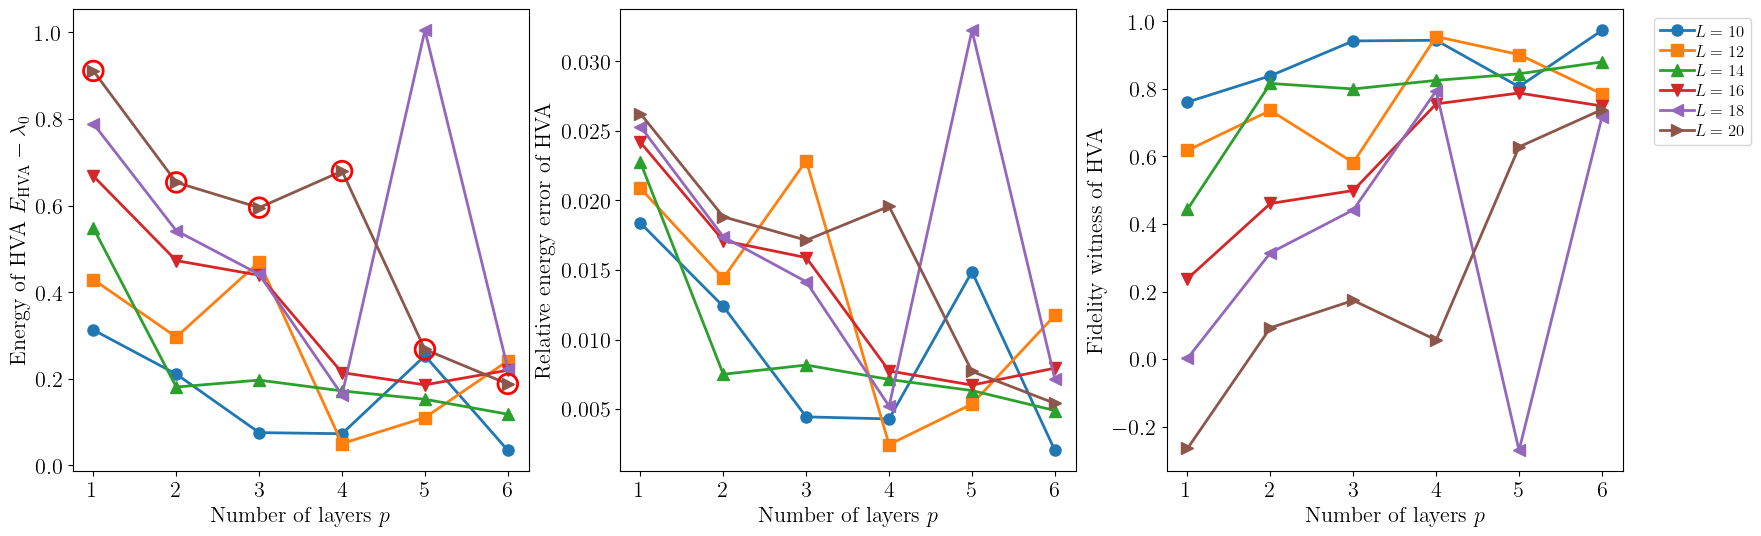

In [ ]:
from db_doi.utils_reporting import run_param_rc, load_data, loading_simulation_data_path
run_param_rc(16)
E_HVA_L = HVA_energies['E_HVA_L']
E0_L = HVA_energies['E0_L']
F_W_L = HVA_energies['F_W_L']
fig, (ax0,ax1,ax2) = plt.subplots(1, 3, figsize=(20, 6), 
                                     gridspec_kw={"width_ratios": [1, 1,1], "height_ratios": [1]})
markers = ['o', 's', '^', 'v', '<', '>', 'd']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i,L in enumerate(HVA_energies['Ls'][2:]):
        
        steps = [1,2,3,4,5,6]
        ax0.plot(steps, E_HVA_L[L]-E0_L[L], color=colors[i], marker=markers[i], linestyle='solid', label = rf"$L={L}$")
        ax0.set_xlabel(r"Number of layers $p$")
        ax0.set_ylabel(r"Energy of HVA $E_{\mathrm{HVA}}-\lambda_0$")

        ax1.plot(steps, abs(E_HVA_L[L]- E0_L[L])/abs(E0_L[L]), color=colors[i], marker=markers[i], linestyle='solid', label = rf"$L={L}$")
        ax1.set_xlabel(r"Number of layers $p$")
        ax1.set_ylabel(r"Relative energy error of HVA")

        ax2.plot(steps, F_W_L[L], color=colors[i], marker=markers[i], linestyle='solid', label = rf"$L={L}$")
        ax2.set_xlabel(r"Number of layers $p$")
        ax2.set_ylabel(r"Fidelity witness of HVA")       
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


for p,E  in zip(steps, E_HVA_L[20]):
        ax0.scatter(p,E-E0_L[L],
                facecolors='none',   # No fill inside the circle
                edgecolors='red',    # Red outline for the circle
                marker='o',          # Circle marker
                s=200,               # Size of the circle (adjust as needed)
                linewidth=2,         # Thickness of the circle's outline
                zorder=5)            # Ensure it's drawn on top
plt.savefig("pdfs_figures/HVA_overview.pdf")